In [7]:
import numpy as np
from Data.Dataset.Dataset import Dataset
from GAS.Population import JSSP, print_console
from GAS.Individual import Individual
from Config.Run_Config import Run_Config
import random
import copy


makespan=dict()
rubi_score=dict()
modes = [1010, 2020, 5050, 100100]
step = [1, 4, 25, 100]
for idx, mode in enumerate(modes):
    dataset = Dataset('test_'+str(mode)+'.txt')
    data = np.array(dataset.op_data)
    config = Run_Config(dataset.n_job, dataset.n_machine, dataset.n_op,population_size=100, generations=400, 
                                 print_console=False, save_log=False, save_machinelog=False, 
                                 show_gantt=False, save_gantt=False, show_gui=False,
                                 trace_object='Process4', title='Gantt Chart for JSSP',
                                 tabu_search_iterations=10, hill_climbing_iterations=30, simulated_annealing_iterations=50,two_iterations=1000)
        
    config.target_makespan = 1
    jssp = JSSP(dataset, print_console=False)
    
    makespan[mode]={'A':[], 'B':[], 'C':[]}
    rubi_score[mode] = {'A':[], 'B':[], 'C':[]}
    
    for i in range(100):    
        seq=jssp.get_seq()
        random.shuffle(seq)
        individual = Individual(config, seq=seq, op_data=dataset.op_data)
        makespan[mode]['A'].append(individual.makespan)
        rubi_score[mode]['A'].append(individual.mio_score)
    for i in range(100):    
        seq=jssp.get_seq()
        temp = copy.deepcopy(seq[step[idx]*i:])
        random.shuffle(temp)
        partial_seq = seq[:step[idx]*i]+temp
        individual = Individual(config, seq=partial_seq, op_data=dataset.op_data)
        makespan[mode]['B'].append(individual.makespan)
        rubi_score[mode]['B'].append(individual.mio_score)
    for i in range(100):    
        seq=jssp.get_seq()
        individual = Individual(config, seq=seq, op_data=dataset.op_data)
        makespan[mode]['C'].append(individual.makespan)
        rubi_score[mode]['C'].append(individual.mio_score)

In [23]:

for idx, mode in enumerate([1010]):
    dataset = Dataset('test_'+str(mode)+'.txt')
    data = np.array(dataset.op_data)
    config = Run_Config(dataset.n_job, dataset.n_machine, dataset.n_op,population_size=100, generations=400, 
                                 print_console=False, save_log=False, save_machinelog=False, 
                                 show_gantt=False, save_gantt=False, show_gui=False,
                                 trace_object='Process4', title='Gantt Chart for JSSP',
                                 tabu_search_iterations=10, hill_climbing_iterations=30, simulated_annealing_iterations=50,two_iterations=1000)
        
    config.target_makespan = 1
    jssp = JSSP(dataset, print_console=False)
    
    makespan[mode]={'A':[], 'B':[], 'C':[]}
    rubi_score[mode] = {'A':[], 'B':[], 'C':[]}
    
    for i in range(100):    
        seq=jssp.get_seq()
        random.shuffle(seq)
        individual = Individual(config, seq=seq, op_data=dataset.op_data)
        makespan[mode]['A'].append(individual.makespan)
        rubi_score[mode]['A'].append(individual.mio_score)
    for i in range(100):    
        seq=jssp.get_seq()
        temp = copy.deepcopy(seq[step[idx]*i:])
        random.shuffle(temp)
        partial_seq = seq[:step[idx]*i]+temp
        individual = Individual(config, seq=partial_seq, op_data=dataset.op_data)
        makespan[mode]['B'].append(individual.makespan)
        rubi_score[mode]['B'].append(individual.mio_score)
    for i in range(100):    
        seq=jssp.get_seq()
        individual = Individual(config, seq=seq, op_data=dataset.op_data)
        makespan[mode]['C'].append(individual.makespan)
        rubi_score[mode]['C'].append(individual.mio_score)

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update(mpl.rcParamsDefault)

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rcParams['font.family'] = 'Times New Roman'

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": 'Times New Roman'
# })
# plt.rcParams.update({'font.size': 14})
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# 두 값의 correlation 계산
corr = dict()
for mode in modes:
    makespan_concat = makespan[mode]['A']+makespan[mode]['B']+makespan[mode]['C']
    rubi_score_concat = rubi_score[mode]['A']+rubi_score[mode]['B']+rubi_score[mode]['C']
    corr[mode]=np.corrcoef(makespan_concat, rubi_score_concat)[0, 1] ** 2
corr

{1010: 0.5342192064705433,
 2020: 0.7293331249603355,
 5050: 0.903806274757814,
 100100: 0.9506896403066629}

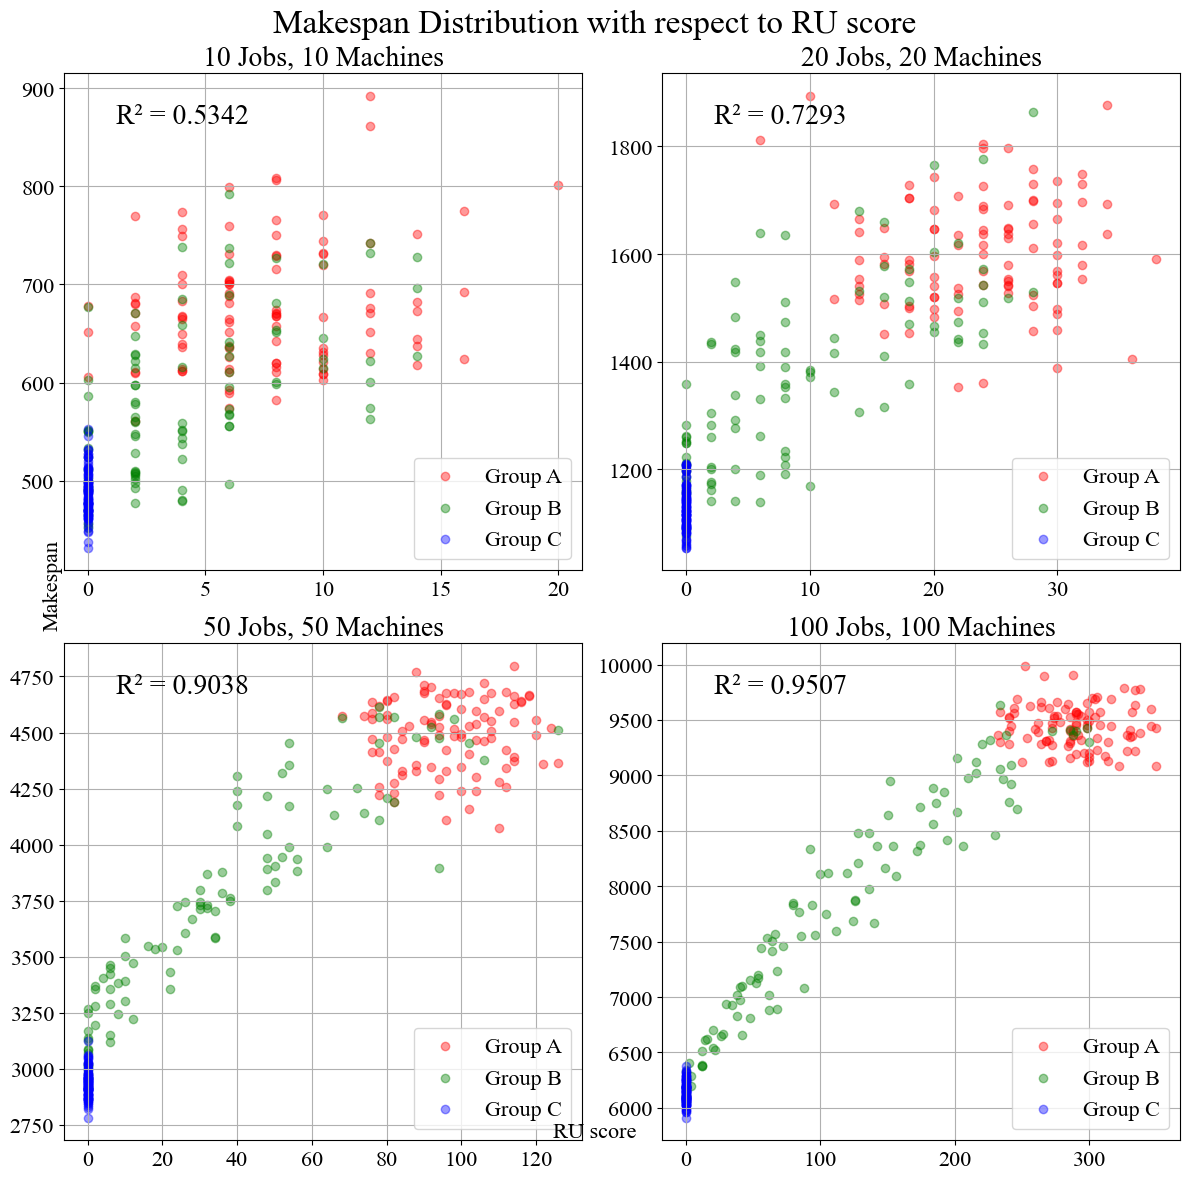

In [34]:
axis_index = [(0,0), (0,1), (1,0), (1,1)]
n_job=[10,20,50,100]
n_machine=[10,20,50,100]
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for idx, mode in enumerate(modes):
    axes[axis_index[idx]].scatter(rubi_score[mode]['A'], makespan[mode]['A'], color='r', alpha=0.4, label='Group A')
    axes[axis_index[idx]].scatter(rubi_score[mode]['B'], makespan[mode]['B'], color='g', alpha=0.4, label='Group B')
    axes[axis_index[idx]].scatter(rubi_score[mode]['C'], makespan[mode]['C'], color='b', alpha=0.4, label='Group C')
    
    # axes[axis_index[idx]].set_xlabel('RU score')
    # axes[axis_index[idx]].set_ylabel('Makespan')
    axes[axis_index[idx]].set_title(f"{n_job[idx]} Jobs, {n_machine[idx]} Machines", fontsize=MEDIUM_SIZE)
    axes[axis_index[idx]].legend(loc='lower right', bbox_to_anchor=(1, 0))
    axes[axis_index[idx]].grid(True)
    axes[axis_index[idx]].text(0.1 , 0.9, f'R² = {corr[mode]:.4f}', transform=axes[axis_index[idx]].transAxes, fontsize=MEDIUM_SIZE)

plt.suptitle("Makespan Distribution with respect to RU score")
# 공통 xlabel, ylabel 설정 (figure 전체 기준 좌표: 0~1)
fig.text(0.5, 0.04, 'RU score', ha='center', fontsize=SMALL_SIZE)   # 아래 중앙
fig.text(0.04, 0.5, 'Makespan', va='center', rotation='vertical', fontsize=SMALL_SIZE)  # 왼쪽 중앙
# 그래프 표시
# plt.tight_layout()
# plt.savefig('Dataset.png', bbox_inches='tight', dpi=300)
plt.savefig('Correlation2_1212.png', dpi=300)
# plt.savefig('Correlation2_1212.eps')
# plt.show()
